<a href="https://colab.research.google.com/github/3sanju/3sanju/blob/main/Revenuetaxiproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

In [127]:
dataset=pd.read_csv('/content/datataxi.csv')

/tmp/ipykernel_1996/3021719254.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset=pd.read_csv('/content/datataxi.csv')


In [128]:
dataset.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [129]:
dataset.shape

(6405008, 18)

In [130]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               float64
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(13), int64(2), object(3)
memory usage: 879.6+ MB


In [131]:
#We convert the datatype of pickup and dropoff time into date an dtime format
dataset['tpep_pickup_datetime']=pd.to_datetime(dataset['tpep_pickup_datetime'])
dataset['tpep_dropoff_datetime']=pd.to_datetime(dataset['tpep_dropoff_datetime'])

In [132]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               float64       
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           float64       
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
dtypes: datetime64[ns](2), 

In [133]:
dataset['duration']=dataset['tpep_dropoff_datetime']-dataset['tpep_pickup_datetime']
dataset['duration']=dataset['duration'].dt.total_seconds()/60


In [134]:
dataset=dataset[['passenger_count','trip_distance','payment_type','fare_amount','duration' ]]
dataset

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1.0,1.20,1.0,6.00,4.800000
1,1.0,1.20,1.0,7.00,7.416667
2,1.0,0.60,1.0,6.00,6.183333
3,1.0,0.80,1.0,5.50,4.850000
4,1.0,0.00,2.0,3.50,2.300000
...,...,...,...,...,...
6405003,NaN,3.24,NaN,17.59,31.000000
6405004,NaN,22.13,NaN,46.67,76.000000
6405005,NaN,10.51,NaN,48.85,27.833333
6405006,NaN,5.49,NaN,27.17,22.650000


In [135]:
dataset.isnull().sum()

,0
passenger_count,65441
trip_distance,0
payment_type,65441
fare_amount,0
duration,0


In [136]:
#Now we have missing value in 2 columns as passenger_count and payment_type so we will check the percentage of missing data in it effecting the dataset
(65441/len(dataset))*100

1.021716132126611

In [137]:
dataset.dropna(inplace=True)

In [138]:
dataset.shape
dataset.isnull().sum()

,0
passenger_count,0
trip_distance,0
payment_type,0
fare_amount,0
duration,0


In [139]:
dataset['passenger_count'] = dataset['passenger_count'].astype('int64')
dataset['payment_type']=dataset['payment_type'].astype('int64')

In [140]:
dataset

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.20,1,6.0,4.800000
1,1,1.20,1,7.0,7.416667
2,1,0.60,1,6.0,6.183333
3,1,0.80,1,5.5,4.850000
4,1,0.00,2,3.5,2.300000
...,...,...,...,...,...
6339562,1,2.10,1,11.0,14.233333
6339563,1,2.13,1,13.0,19.000000
6339564,1,2.55,1,12.5,16.283333
6339565,1,1.61,2,8.5,9.633333


In [141]:
dataset[dataset.duplicated()]

,passenger_count,trip_distance,payment_type,fare_amount,duration
2056,1,0.00,2,7.0,0.000000
2441,1,0.00,1,52.0,0.200000
2446,2,1.70,1,9.5,13.066667
2465,1,0.40,1,4.0,3.083333
3344,1,1.20,1,6.0,5.350000
...,...,...,...,...,...
6339558,1,1.63,2,8.0,8.800000
6339559,1,1.81,1,8.5,8.016667
6339560,1,0.98,2,6.5,6.900000
6339562,1,2.10,1,11.0,14.233333


In [142]:
#We remove duplicates value from the data as they do not contribute in analysis
dataset.drop_duplicates(inplace=True)

In [143]:
dataset

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.20,1,6.0,4.800000
1,1,1.20,1,7.0,7.416667
2,1,0.60,1,6.0,6.183333
3,1,0.80,1,5.5,4.850000
4,1,0.00,2,3.5,2.300000
...,...,...,...,...,...
6339555,3,2.09,1,10.0,14.800000
6339561,1,4.11,1,17.5,21.500000
6339563,1,2.13,1,13.0,19.000000
6339564,1,2.55,1,12.5,16.283333


In [144]:
dataset.shape

(3007861, 5)

In [145]:
dataset['passenger_count'].value_counts(normalize=True)

,proportion
passenger_count,
1,0.581981
2,0.190350
3,0.066360
5,0.062937
6,0.039272
4,0.036046
0,0.023033
7,0.000009
9,0.000006


In [146]:
dataset=dataset[dataset['payment_type']<3]
dataset=dataset[(dataset['passenger_count']>0)& (dataset['passenger_count']<6)]

In [147]:
dataset.shape

(2780283, 5)

In [148]:
dataset

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.20,1,6.0,4.800000
1,1,1.20,1,7.0,7.416667
2,1,0.60,1,6.0,6.183333
3,1,0.80,1,5.5,4.850000
4,1,0.00,2,3.5,2.300000
...,...,...,...,...,...
6339555,3,2.09,1,10.0,14.800000
6339561,1,4.11,1,17.5,21.500000
6339563,1,2.13,1,13.0,19.000000
6339564,1,2.55,1,12.5,16.283333


In [149]:
dataset['payment_type'].replace([1,2],['Card','Cash'],inplace=True)

/tmp/ipykernel_1996/3040430361.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['payment_type'].replace([1,2],['Card','Cash'],inplace=True)


In [150]:
dataset

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.20,Card,6.0,4.800000
1,1,1.20,Card,7.0,7.416667
2,1,0.60,Card,6.0,6.183333
3,1,0.80,Card,5.5,4.850000
4,1,0.00,Cash,3.5,2.300000
...,...,...,...,...,...
6339555,3,2.09,Card,10.0,14.800000
6339561,1,4.11,Card,17.5,21.500000
6339563,1,2.13,Card,13.0,19.000000
6339564,1,2.55,Card,12.5,16.283333


In [151]:
dataset.describe() #By this we come to know that our data has so much outliers (by seeing 75% and max)

,passenger_count,trip_distance,fare_amount,duration
count,2.780283e+06,2.780283e+06,2.780283e+06,2.780283e+06
mean,1.733386e+00,4.536729e+00,1.780567e+01,2.415478e+01
std,1.176652e+00,4.895890e+00,1.506997e+01,9.260031e+01
min,1.000000e+00,-2.218000e+01,-5.000000e+02,-2.770367e+03
25%,1.000000e+00,1.500000e+00,9.000000e+00,9.883333e+00
50%,1.000000e+00,2.730000e+00,1.300000e+01,1.573333e+01
75%,2.000000e+00,5.470000e+00,2.100000e+01,2.336667e+01
max,5.000000e+00,2.628800e+02,4.265000e+03,8.525117e+03


In [152]:
dataset=dataset[dataset['trip_distance']>0]
dataset=dataset[dataset['fare_amount']>0]
dataset=dataset[dataset['duration']>0]

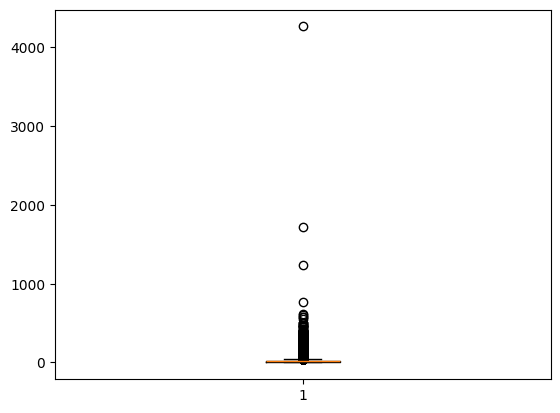

In [153]:
plt.boxplot(dataset['fare_amount'])
plt.show()

In [154]:
#To remove outliers we use interquartile range method here as the data does not found to be standard normalised

In [155]:
for col in ['trip_distance','fare_amount','duration']:
  q1=dataset[col].quantile(0.25)
  q3=dataset[col].quantile(0.75)
  iqr=q3-q1


lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

dataset=dataset[(dataset[col]>=lower_bound) & (dataset[col]<=upper_bound)]
dataset

,passenger_count,trip_distance,payment_type,fare_amount,duration
0,1,1.20,Card,6.0,4.800000
1,1,1.20,Card,7.0,7.416667
2,1,0.60,Card,6.0,6.183333
3,1,0.80,Card,5.5,4.850000
5,1,0.03,Cash,2.5,0.883333
...,...,...,...,...,...
6339550,4,2.40,Card,10.5,12.383333
6339555,3,2.09,Card,10.0,14.800000
6339561,1,4.11,Card,17.5,21.500000
6339563,1,2.13,Card,13.0,19.000000


In [156]:
dataset.describe() #Now outliers have been removed

,passenger_count,trip_distance,fare_amount,duration
count,2.634401e+06,2.634401e+06,2.634401e+06,2.634401e+06
mean,1.748170e+00,4.118692e+00,1.634112e+01,1.659009e+01
std,1.186476e+00,4.158539e+00,1.200690e+01,9.061194e+00
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,1.500000e+00,8.500000e+00,9.700000e+00
50%,1.000000e+00,2.660000e+00,1.300000e+01,1.525000e+01
75%,2.000000e+00,5.000000e+00,1.950000e+01,2.211667e+01
max,5.000000e+00,8.593000e+01,5.000000e+02,4.340000e+01


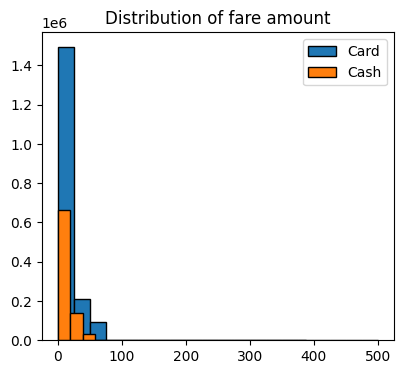

In [157]:
plt.figure(figsize=(10,4))
plt.subplot( 1,2,1)
plt.title('Distribution of fare amount')
plt.hist(dataset[dataset['payment_type']=='Card']['fare_amount'],histtype='barstacked' ,bins=20,edgecolor='k',label='Card')
plt.hist(dataset[dataset['payment_type']=='Cash']['fare_amount'],histtype='barstacked' ,bins=20,edgecolor='k',label='Cash')
plt.legend()
plt.show()

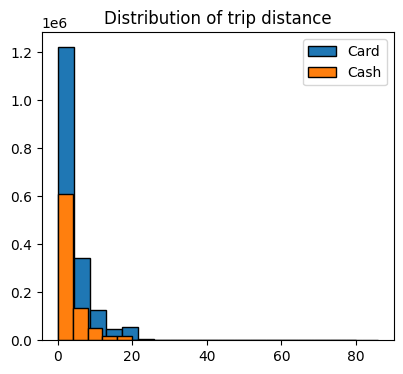

In [158]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Distribution of trip distance")
plt.hist(dataset[dataset['payment_type']=='Card']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',label='Card')
plt.hist(dataset[dataset['payment_type']=='Cash']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',label='Cash')
plt.legend()
plt.show()



In [159]:
dataset.groupby('payment_type').agg({'fare_amount':['mean','std'], 'trip_distance':['mean','std']})

fare_amount            trip_distance          
                    mean        std          mean       std
payment_type                                               
Card           17.157378  12.461771      4.361608  4.300681
Cash           14.581804  10.753858      3.595122  3.781606

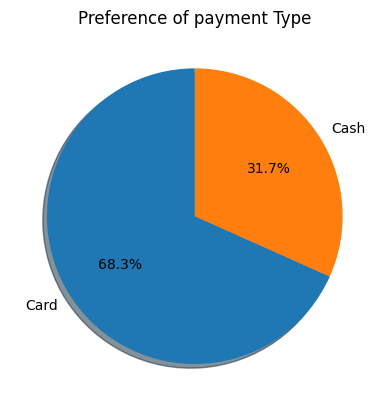

In [109]:
plt.title("Preference of payment Type")
plt.pie(dataset['payment_type'].value_counts(normalize=True), labels=dataset['payment_type'].value_counts().index,
  startangle=90,shadow=True, autopct='%.1f%%')
plt.show()

In [110]:
passenger_count=dataset.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns={'passenger_count':'count'},inplace=True)
passenger_count.reset_index(inplace=True)


In [111]:
passenger_count['perc']=(passenger_count['count']/passenger_count['count'].sum())*100

In [112]:
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,1094441,41.544207
1,Card,2,370391,14.059781
2,Card,3,132801,5.041032
3,Card,4,68650,2.605905
4,Card,5,133218,5.056861
5,Cash,1,519599,19.723611
6,Cash,2,170890,6.486864
7,Cash,3,58658,2.226616
8,Cash,4,35052,1.330549
9,Cash,5,50701,1.924574


In [121]:
dataset_new=pd.DataFrame(columns=['payment_type',1,2,3,4,5])
dataset_new['payment_type']=['Card','Cash']
dataset_new.iloc[0,1:]=passenger_count.iloc[0:5,-1]
dataset_new.iloc[1,1:]=passenger_count.iloc[5:,-1]
dataset_new

,payment_type,1,2,3,4,5
0,Card,41.544207,14.059781,5.041032,2.605905,5.056861
1,Cash,19.723611,6.486864,2.226616,1.330549,1.924574


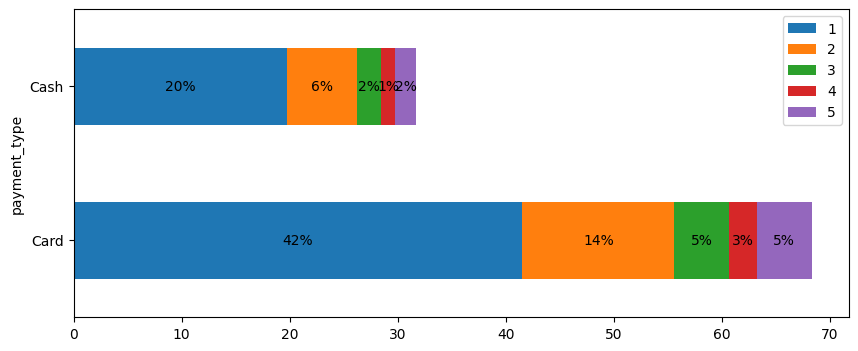

In [122]:
fig, ax = plt.subplots(figsize=(10,4))

dataset_new.plot(
    x='payment_type',
    kind='barh',
    stacked=True,
    ax=ax
)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()

    ax.text(
        x + width/2,
        y + height/2,
        '{:.0f}%'.format(width),
        ha='center',
        va='center'
    )

plt.show()

In [115]:
#To confirm our results to stackholders we use hypothesis testing

In [116]:
#We consider Null Hypthesis and Alternative Hypothesis
#Null Hypothesis: Their is no difference between the average fare of Card and Cash Users
#Alternative Hypothesis: Their is difference between the average fare of Card and Cash users

In [161]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2634401 entries, 0 to 6339564
Data columns (total 5 columns):
 #   Column           Dtype  
---  ------           -----  
 0   passenger_count  int64  
 1   trip_distance    float64
 2   payment_type     object 
 3   fare_amount      float64
 4   duration         float64
dtypes: float64(3), int64(1), object(1)
memory usage: 120.6+ MB


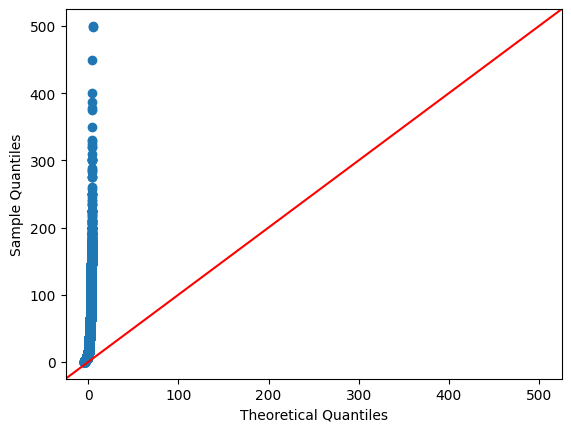

In [160]:
sm.qqplot(dataset['fare_amount'],line='45')
plt.show() #Thus this plot show that the data is very far from the 45 line so it's not normalized so we can go with T-Test as Z test condition fails here

In [168]:
from IPython.core.application import crashhandler
#Sample For T-Test
card_sample=dataset[dataset['payment_type']=='Card']['fare_amount']
cash_sample=dataset[dataset['payment_type']=='Cash']['fare_amount']

In [170]:
#Ttest Formula
t_stats,p_value=st.ttest_ind(a=card_sample,b=cash_sample,equal_var=False)
print('T statistics',t_stats,'P value',p_value)

T statistics 171.77614698135315 P value 0.0


In [ ]:
#The above results show that the value of p is very less than the sigma value that is 0.05 therefore we will reject the null hypothesis and go with the alternative one